# Tutorial 5: Neural Architecture Search (NAS) with Mase and Optuna

In this tutorial, we'll see how Mase can be integrated with Optuna, the popular hyperparameter optimization framework, to search for a Bert model optimized for sequence classification on the IMDb dataset. We'll take the Optuna-generated model and import it into Mase, then run the CompressionPipeline to prepare the model for edge deployment by quantizing and pruning its weights.

As we'll see, running Architecture Search with Mase/Optuna involves the following steps.

1. **Define the search space**: this is a dictionary containing the range of values for each parameter at each layer in the model.

2. **Write the model constructor**: this is a function which uses Optuna utilities to sample a model from the search space, and constructs the model using transformers from_config class method.

3. **Write the objective function**: this function calls on the model constructor defined in Step 2 and defines the training/evaluation setup for each search iteration.

4. **Go!** Choose an Optuna sampler, create a study and launch the search.

In [11]:
checkpoint = "prajjwal1/bert-tiny"
tokenizer_checkpoint = "bert-base-uncased"
dataset_name = "imdb"

First, fetch the dataset using the `get_tokenized_dataset` utility.

In [12]:
from chop.tools import get_tokenized_dataset

dataset, tokenizer = get_tokenized_dataset(
    dataset=dataset_name,
    checkpoint=tokenizer_checkpoint,
    return_tokenizer=True,
)

INFO     Tokenizing dataset imdb with AutoTokenizer for bert-base-uncased.


## 1. Defining the Search Space

We'll start by defining a search space, i.e. enumerating the possible combinations of hyperparameters that Optuna can choose during search. We'll explore the following range of values for the model's hidden size, intermediate size, number of layers and number of heads, inspired by the [NAS-BERT paper](https://arxiv.org/abs/2105.14444).

In [13]:
import torch.nn as nn
from chop.nn.modules import Identity

search_space = {
    "num_layers": [2, 4, 8],
    "num_heads": [2, 4, 8, 16],
    "hidden_size": [128, 192, 256, 384, 512],
    "intermediate_size": [512, 768, 1024, 1536, 2048],
    "linear_layer_choices": [
        nn.Linear,
        Identity,
    ],
}

## 2. Writing a Model Constructor

We define the following function, which will get called in each iteration of the search process. The function is passed the `trial` argument, which is an Optuna object that comes with many functionalities - see the [Trial documentation](https://optuna.readthedocs.io/en/stable/reference/trial.html) for more details. Here, we use the `trial.suggest_int` and `trial.suggest_categorical` functions to trigger the chosen sampler to choose parameter choices and layer types. The suggested integer is the index into the search space for each parameter, which we defined in the previous cell.

In [14]:
from transformers import AutoConfig, AutoModelForSequenceClassification
from chop.tools.utils import deepsetattr


def construct_model(trial):
    config = AutoConfig.from_pretrained(checkpoint)

    # Update the paramaters in the config
    for param in [
        "num_layers",
        "num_heads",
        "hidden_size",
        "intermediate_size",
    ]:
        chosen_idx = trial.suggest_int(param, 0, len(search_space[param]) - 1)
        setattr(config, param, search_space[param][chosen_idx])

    trial_model = AutoModelForSequenceClassification.from_config(config)

    for name, layer in trial_model.named_modules():
        if isinstance(layer, nn.Linear) and layer.in_features == layer.out_features:
            new_layer_cls = trial.suggest_categorical(
                f"{name}_type",
                search_space["linear_layer_choices"],
            )

            if new_layer_cls == nn.Linear:
                continue
            elif new_layer_cls == Identity:
                new_layer = Identity()
                deepsetattr(trial_model, name, new_layer)
            else:
                raise ValueError(f"Unknown layer type: {new_layer_cls}")

    return trial_model

## 3. Defining the Objective Function

Next, we define the objective function for the search, which gets called on each trial. In each trial, we create a new model instace with chosen hyperparameters according to the defined sampler. We then use the `get_trainer` utility in Mase to run a training loop on the IMDb dataset for a number of epochs. Finally, we use `evaluate` to report back the classification accuracy on the test split.

In [15]:
from chop.tools import get_trainer


def objective(trial):

    # Define the model
    model = construct_model(trial)

    trainer = get_trainer(
        model=model,
        tokenized_dataset=dataset,
        tokenizer=tokenizer,
        evaluate_metric="accuracy",
        num_train_epochs=1,
    )

    trainer.train()
    eval_results = trainer.evaluate()

    # Set the model as an attribute so we can fetch it later
    trial.set_user_attr("model", model)

    return eval_results["eval_accuracy"]

## 4. Launching the Search

Optuna provides a number of samplers, for example:

* **GridSampler**: iterates through every possible combination of hyperparameters in the search space
* **RandomSampler**: chooses a random combination of hyperparameters in each iteration
* **TPESampler**: uses Tree-structured Parzen Estimator algorithm to choose hyperparameter values.

You can define the chosen sampler by simply importing from `optuna.samplers` as below.

In [33]:
from optuna.samplers import GridSampler, RandomSampler, TPESampler

sampler = RandomSampler()

With all the pieces in place, we can launch the search as follows. The number of trials is set to 1 so you can go get a coffee for 10 minutes, then proceed with the tutorial. However, this will essentially be a random model - for better results, set this to 100 and leave it running overnight!

In [20]:
import optuna

study = optuna.create_study(
    direction="maximize",
    study_name="bert-tiny-nas-study",
    sampler=sampler,
)

study.optimize(
    objective,
    n_trials=1,
    timeout=60 * 60 * 24,
)

[I 2025-01-27 16:22:01,571] A new study created in memory with name: bert-tiny-nas-study


Step,Training Loss


[W 2025-01-27 16:22:48,331] Trial 0 failed with parameters: {'num_layers': 4, 'num_heads': 4, 'hidden_size': 192, 'intermediate_size': 512, 'linear_layer_choices': 'linear'} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "/Users/nyalpatel/anaconda3/envs/mase/lib/python3.11/site-packages/optuna/study/_optimize.py", line 197, in _run_trial
    value_or_values = func(trial)
                      ^^^^^^^^^^^
  File "/var/folders/30/jp8jpmfj5v789rzp519s48pw0000gn/T/ipykernel_32133/1213065657.py", line 110, in objective
    trainer.train()
  File "/Users/nyalpatel/anaconda3/envs/mase/lib/python3.11/site-packages/transformers/trainer.py", line 2171, in train
    return inner_training_loop(
           ^^^^^^^^^^^^^^^^^^^^
  File "/Users/nyalpatel/anaconda3/envs/mase/lib/python3.11/site-packages/transformers/trainer.py", line 2531, in _inner_training_loop
    tr_loss_step = self.training_step(model, inputs, num_items_in_batch)
                   ^

KeyboardInterrupt: 

Fetch the model associated with the best trial as follows, and export to be used in future tutorials. In Tutorial 6, we'll see how to run mixed-precision quantization search on top of the model we've just found through NAS to further find the optimal quantization mapping.

In [11]:
from pathlib import Path
import dill

model = study.best_trial.user_attrs["model"].cpu()

with open(f"tutorial_5_best_model.pkl", "wb") as f:
    dill.dump(model, f)

## Deploying the Optimized Model with CompressionPipeline

Now, we can run the CompressionPipeline in Mase to run uniform quantization and pruning over the searched model.

In [9]:
from chop.pipelines import CompressionPipeline
from chop import MaseGraph

mg = MaseGraph(model)
pipe = CompressionPipeline()

quantization_config = {
    "by": "type",
    "default": {
        "config": {
            "name": None,
        }
    },
    "linear": {
        "config": {
            "name": "integer",
            # data
            "data_in_width": 8,
            "data_in_frac_width": 4,
            # weight
            "weight_width": 8,
            "weight_frac_width": 4,
            # bias
            "bias_width": 8,
            "bias_frac_width": 4,
        }
    },
}

pruning_config = {
    "weight": {
        "sparsity": 0.5,
        "method": "l1-norm",
        "scope": "local",
    },
    "activation": {
        "sparsity": 0.5,
        "method": "l1-norm",
        "scope": "local",
    },
}

mg, _ = pipe(
    mg,
    pass_args={
        "quantize_transform_pass": quantization_config,
        "prune_transform_pass": pruning_config,
    },
)

`past_key_values` were not specified as input names, but model.config.use_cache = True. Setting model.config.use_cache = False.
INFO     Getting dummy input for prajjwal1/bert-tiny.
INFO     Pruning module: bert_encoder_layer_0_attention_self_value
INFO     Pruning module: bert_encoder_layer_0_intermediate_dense
INFO     Pruning module: bert_encoder_layer_0_output_dense
INFO     Pruning module: bert_encoder_layer_1_attention_self_query
INFO     Pruning module: bert_encoder_layer_1_attention_self_value
INFO     Pruning module: bert_encoder_layer_1_intermediate_dense
INFO     Pruning module: bert_encoder_layer_1_output_dense


tensor([[ 101, 9932, 2089, 2202, 2058, 1996, 2088, 2028, 2154,  102],
        [ 101, 2023, 2003, 2339, 2017, 2323, 4553, 4748, 4877,  102]])
tensor([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0]])
tensor([[ 101, 9932, 2089, 2202, 2058, 1996, 2088, 2028, 2154,  102],
        [ 101, 2023, 2003, 2339, 2017, 2323, 4553, 4748, 4877,  102]])
tensor([[1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1., 1., 1., 1., 1.]])
tensor([[1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1., 1., 1., 1., 1.]])
tensor([[1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1., 1., 1., 1., 1.]])
tensor([[[[1., 1., 1., 1., 1., 1., 1., 1., 1., 1.]]],


        [[[1., 1., 1., 1., 1., 1., 1., 1., 1., 1.]]]])
tensor([[[[1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
          [1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
          [1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
          [1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
          [1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
   

INFO     Pruning module: classifier


Finally, export the MaseGraph for the compressed checkpoint to be used in future tutorials for hardware generation and distributed deployment.

In [ ]:
import torch

#mg.export(f"tutorial_5_nas_compressed")
torch.save(mg.model.state_dict(), "tutorial_5_nas_compressed.pt")

### Tasks

# Task 1 - varying sampler - GRID and TPE and RANDOM

In [ ]:
import torch.nn as nn
from chop.nn.modules import Identity
from transformers import AutoConfig, AutoModelForSequenceClassification
from chop.tools.utils import deepsetattr
from chop.tools import get_tokenized_dataset, get_trainer
import optuna
from optuna.samplers import GridSampler, TPESampler, RandomSampler
import matplotlib.pyplot as plt
import dill
from pathlib import Path
import pandas as pd

# -----------------------------
# 1. Define your checkpoints & dataset
# -----------------------------
checkpoint = "prajjwal1/bert-tiny"
tokenizer_checkpoint = "bert-base-uncased"
dataset_name = "imdb"

# Load tokenized dataset and tokenizer
dataset, tokenizer = get_tokenized_dataset(
    dataset=dataset_name,
    checkpoint=tokenizer_checkpoint,
    return_tokenizer=True,
)

# -----------------------------
# 2. Define search space
# -----------------------------
grid_search_space = {
    "num_layers": [2, 4, 8],
    "num_heads": [2, 4, 8, 16],
    "hidden_size": [128, 192, 256, 384, 512],
    "intermediate_size": [512, 768, 1024, 1536, 2048],
    "linear_layer_choices": ["linear", "identity"],
}

# Same discrete sets for TPE/Random:
tpe_search_space = {
    "num_layers": [2, 4, 8],
    "num_heads": [2, 4, 8, 16],
    "hidden_size": [128, 192, 256, 384, 512],
    "intermediate_size": [512, 768, 1024, 1536, 2048],
    "linear_layer_choices": ["linear", "identity"],
}


# -----------------------------
# 3. Construct the model given a trial
# -----------------------------
def construct_model(trial):
    """
    Creates a BERT model with the hyperparameters suggested by the trial.
    We manually map each parameter to the correct config attribute or layer override.
    """
    # Load the default config from a small BERT checkpoint
    config = AutoConfig.from_pretrained(checkpoint)

    # Map parameters to config
    config.num_hidden_layers = trial.suggest_categorical(
        "num_layers", tpe_search_space["num_layers"]
    )
    config.num_attention_heads = trial.suggest_categorical(
        "num_heads", tpe_search_space["num_heads"]
    )
    config.hidden_size = trial.suggest_categorical(
        "hidden_size", tpe_search_space["hidden_size"]
    )
    config.intermediate_size = trial.suggest_categorical(
        "intermediate_size", tpe_search_space["intermediate_size"]
    )

    model = AutoModelForSequenceClassification.from_config(config)

    # Handle linear layer choice
    linear_choice = trial.suggest_categorical(
        "linear_layer_choices", tpe_search_space["linear_layer_choices"]
    )
    
    if linear_choice == "identity":
        # For each linear layer that is square (in_features == out_features),
        # replace it with Identity
        for name, layer in model.named_modules():
            if isinstance(layer, nn.Linear) and layer.in_features == layer.out_features:
                deepsetattr(model, name, Identity())

    return model


# -----------------------------
# 4. Define the objective function
# -----------------------------
def objective(trial):
    # Build the model given the trial
    trial_model = construct_model(trial)

    # Create a Trainer (from chop) that handles fine-tuning
    trainer = get_trainer(
        model=trial_model,
        tokenized_dataset=dataset,
        tokenizer=tokenizer,
        evaluate_metric="accuracy",
        num_train_epochs=1,  # For demonstration only
    )

    # Train and evaluate
    trainer.train()
    eval_results = trainer.evaluate()

    # Save the model to the trial user attributes for later retrieval if needed
    trial.set_user_attr("model", trial_model)

    # Return the metric you want to optimize
    return eval_results["eval_accuracy"]


# -----------------------------
# 5. Helper to run a study and collect "running best accuracies"
# -----------------------------
def run_study_and_get_curve(sampler, n_trials=None, study_name="study"):
    """
    Runs an Optuna study with the provided sampler and returns:
      - the study object
      - a list of best accuracies up to each trial (running max)
    """
    study = optuna.create_study(
        direction="maximize",
        study_name=study_name,
        sampler=sampler,
    )

    study.optimize(
        objective,
        n_trials=n_trials,
        timeout=60 * 60 * 24,  # or specify a time limit
        show_progress_bar=False,
    )

    # Build a list of max accuracies up to each trial
    running_max_accuracies = []
    current_max = 0.0
    for t in study.trials:
        if t.value is not None and t.value > current_max:
            current_max = t.value
        running_max_accuracies.append(current_max)

    return study, running_max_accuracies

# -----------------------------
# 6. Function to save trials data to CSV
# -----------------------------
def save_study_results_to_csv(study, filename):
    """
    Saves each trial's results into a CSV, including:
      - trial number
      - objective value (accuracy)
      - parameters
      - model config parameters
    """
    rows = []
    for t in study.trials:
        row = {
            "trial_number": t.number,
            "accuracy": t.value,
        }
        # Merge in parameter key-value pairs directly
        row.update(t.params)

        # Add model config if it exists in user attributes
        if "model" in t.user_attrs:
            model_config = t.user_attrs["model"].config.to_dict()
            for key, value in model_config.items():
                row[f"config_{key}"] = value

        rows.append(row)

    df = pd.DataFrame(rows)
    df.to_csv(filename, index=False)
    print(f"Saved {len(rows)} trials with model configs to {filename}.")



# -----------------------------
# 7. Compare GridSampler vs TPESampler vs RandomSampler
# -----------------------------
if __name__ == "__main__":
    # For GridSampler, define discrete search space
    grid_sampler = GridSampler(
        search_space={
            "num_layers": grid_search_space["num_layers"],
            "num_heads": grid_search_space["num_heads"],
            "hidden_size": grid_search_space["hidden_size"],
            "intermediate_size": grid_search_space["intermediate_size"],
            "linear_layer_choices": grid_search_space["linear_layer_choices"],
        }
    )

    #tpe_sampler = TPESampler()
    random_sampler = RandomSampler()

    # ---------------------------------------
    # 7a. Run with GridSampler
    # ---------------------------------------
    grid_study, grid_max_curve = run_study_and_get_curve(
        sampler=grid_sampler,
        n_trials=10,  # product of all combos if you set this None or a bigger number
        study_name="bert-grid-study",
    )
    print(f"[GridSampler] Number of trials: {len(grid_study.trials)}")
    print(f"[GridSampler] Best accuracy: {grid_study.best_value:.4f}")

    # ---------------------------------------
    # 7b. Run with TPESampler
    # ---------------------------------------
    tpe_study, tpe_max_curve = run_study_and_get_curve(
        sampler=tpe_sampler,
        n_trials=10,  # pick more if desired
        study_name="bert-tpe-study",
    )
    print(f"[TPESampler] Number of trials: {len(tpe_study.trials)}")
    print(f"[TPESampler] Best accuracy: {tpe_study.best_value:.4f}")

    # ---------------------------------------
    # 7c. Run with RandomSampler
    # ---------------------------------------
    random_study, random_max_curve = run_study_and_get_curve(
        sampler=random_sampler,
        n_trials=10,  # pick more if desired
        study_name="bert-random-study",
    )
    print(f"[RandomSampler] Number of trials: {len(random_study.trials)}")
    print(f"[RandomSampler] Best accuracy: {random_study.best_value:.4f}")

    # -----------------------------
    # 8. Plot the results
    # -----------------------------
    plt.figure(figsize=(8, 6))
    #plt.plot(range(1, len(grid_max_curve)+1), grid_max_curve, label="GridSampler")
    #plt.plot(range(1, len(tpe_max_curve)+1), tpe_max_curve, label="TPESampler")
    plt.plot(range(1, len(random_max_curve)+1), random_max_curve, label="RandomSampler")
    plt.xlabel("Number of Trials")
    plt.ylabel("Max Accuracy So Far")
    plt.title("Comparison of GridSampler vs TPESampler vs RandomSampler")
    plt.legend()
    plt.show()

    # -----------------------------
    # 9. (Optional) Save best models
    # -----------------------------
    best_grid_model = grid_study.best_trial.user_attrs["model"].cpu()
    with open("best_grid_model.pkl", "wb") as f:
        dill.dump(best_grid_model, f)

    best_tpe_model = tpe_study.best_trial.user_attrs["model"].cpu()
    with open("best_tpe_model.pkl", "wb") as f:
        dill.dump(best_tpe_model, f)

    best_random_model = random_study.best_trial.user_attrs["model"].cpu()
    with open("best_random_model.pkl", "wb") as f:
        dill.dump(best_random_model, f)

    # -----------------------------
    # 10. Save all trials to CSV
    # -----------------------------
    save_study_results_to_csv(grid_study, "grid_study_trials.csv")
    save_study_results_to_csv(tpe_study, "tpe_study_trials.csv")
    save_study_results_to_csv(random_study, "random_study_trials.csv")


INFO     Tokenizing dataset imdb with AutoTokenizer for bert-base-uncased.
[I 2025-01-28 11:49:51,066] A new study created in memory with name: bert-grid-study
/Users/nyalpatel/Library/CloudStorage/OneDrive-Personal/Uni/Imperial MSC/Modules/Advanced Deep Learning/Labs/mase/src/chop/tools/huggingface.py:157: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Step,Training Loss


[I 2025-01-28 12:08:45,587] Trial 0 finished with value: 0.5 and parameters: {'num_layers': 8, 'num_heads': 2, 'hidden_size': 384, 'intermediate_size': 1536, 'linear_layer_choices': 'linear'}. Best is trial 0 with value: 0.5.
[I 2025-01-28 12:08:45,607] A new study created in memory with name: bert-tpe-study


[GridSampler] Number of trials: 1
[GridSampler] Best accuracy: 0.5000


/Users/nyalpatel/Library/CloudStorage/OneDrive-Personal/Uni/Imperial MSC/Modules/Advanced Deep Learning/Labs/mase/src/chop/tools/huggingface.py:157: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Step,Training Loss


[W 2025-01-28 12:08:58,158] Trial 0 failed with parameters: {'num_layers': 8, 'num_heads': 4, 'hidden_size': 512, 'intermediate_size': 2048, 'linear_layer_choices': 'linear'} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "/Users/nyalpatel/anaconda3/envs/mase/lib/python3.11/site-packages/optuna/study/_optimize.py", line 197, in _run_trial
    value_or_values = func(trial)
                      ^^^^^^^^^^^
  File "/var/folders/30/jp8jpmfj5v789rzp519s48pw0000gn/T/ipykernel_32133/3011741706.py", line 106, in objective
    trainer.train()
  File "/Users/nyalpatel/anaconda3/envs/mase/lib/python3.11/site-packages/transformers/trainer.py", line 2171, in train
    return inner_training_loop(
           ^^^^^^^^^^^^^^^^^^^^
  File "/Users/nyalpatel/anaconda3/envs/mase/lib/python3.11/site-packages/transformers/trainer.py", line 2531, in _inner_training_loop
    tr_loss_step = self.training_step(model, inputs, num_items_in_batch)
                   

KeyboardInterrupt: 

# Task 2  - Compression Pipeline

In [ ]:
import optuna
from optuna.samplers import TPESampler

import torch.nn as nn
import matplotlib.pyplot as plt

from transformers import AutoConfig, AutoModelForSequenceClassification

import pandas as pd

def save_study_results_to_csv(study, filename):
    trials_data = []
    for trial in study.get_trials(deepcopy=False):
        trials_data.append({
            "trial_number": trial.number,
            "value": trial.value,
            "params": trial.params,
            "user_attrs": trial.user_attrs,
        })
    # Convert the trials data to a DataFrame
    df = pd.DataFrame(trials_data)
    # Save to CSV
    df.to_csv(filename, index=False)

# ---------------------------
# 1) PREPARE DATA + TRAINER
# ---------------------------
# MASE helpers
from chop.tools import get_tokenized_dataset, get_trainer, deepsetattr
from chop.pipelines import CompressionPipeline
from chop import MaseGraph
from chop.nn.modules import Identity


# For demonstration:
checkpoint = "prajjwal1/bert-tiny"
tokenizer_checkpoint = "bert-base-uncased"
dataset_name = "imdb"

dataset, tokenizer = get_tokenized_dataset(
    dataset=dataset_name,
    checkpoint=tokenizer_checkpoint,
    return_tokenizer=True,
)

# ---------------------------
# 2) DEFINE SEARCH SPACE
# ---------------------------
search_space = {
    "num_layers": [2, 4, 8],
    "num_heads": [2, 4, 8, 16],
    "hidden_size": [128, 192, 256, 384, 512],
    "intermediate_size": [512, 768, 1024, 1536, 2048],
    "linear_layer_choices": [
        nn.Linear,
        Identity,
    ],
}

def construct_model(trial):
    config = AutoConfig.from_pretrained(checkpoint)

    # Update the paramaters in the config
    for param in [
        "num_layers",
        "num_heads",
        "hidden_size",
        "intermediate_size",
    ]:
        chosen_idx = trial.suggest_int(param, 0, len(search_space[param]) - 1)
        chosen_value = search_space[param][chosen_idx]
        setattr(config, param, chosen_value)  # Set the actual value in the config
        
        print(f"{param}: Chosen index = {chosen_idx}, Chosen value = {chosen_value}")


    trial_model = AutoModelForSequenceClassification.from_config(config)

    for name, layer in trial_model.named_modules():
        if isinstance(layer, nn.Linear) and layer.in_features == layer.out_features:
            new_layer_cls = trial.suggest_categorical(
                f"{name}_type",
                search_space["linear_layer_choices"],
            )

            if new_layer_cls == nn.Linear:
                continue
            elif new_layer_cls == Identity:
                new_layer = Identity()
                deepsetattr(trial_model, name, new_layer)
            else:
                raise ValueError(f"Unknown layer type: {new_layer_cls}")

    return trial_model


# ---------------------------
# 3) BASELINE (NO COMPRESSION)
# ---------------------------
def objective_baseline(trial):
    """
    Standard objective: train for a short time and return accuracy.
    """
    model = construct_model(trial)
    trainer = get_trainer(
        model=model,
        tokenized_dataset=dataset,
        tokenizer=tokenizer,
        evaluate_metric="accuracy",
        num_train_epochs=1,  # e.g. 1 epoch for demonstration
    )
    trainer.train()
    eval_results = trainer.evaluate()
    final_acc = eval_results["eval_accuracy"]

    # Store model if you want to retrieve it later
    trial.set_user_attr("model", model)
    return final_acc

# Create + run the baseline study
study_baseline = optuna.create_study(
    direction="maximize",
    study_name="bert-tiny-nas-baseline-tpe",
    sampler=TPESampler(seed=0),
)
study_baseline.optimize(
    objective_baseline,
    n_trials=3,         # demo: 5 trials
    timeout=60*30,      # 30 min limit, adjust as needed
)

# Compute running "best so far" for baseline
trials_baseline = study_baseline.get_trials(deepcopy=False)
best_so_far_baseline = []
current_max = float("-inf")
for t in trials_baseline:
    if t.value is not None:
        current_max = max(current_max, t.value)
    best_so_far_baseline.append(current_max)

# Save baseline study results
save_study_results_to_csv(study_baseline, "baseline_study_results.csv")



# ---------------------------
# 4) COMPRESSION‐AWARE (NO POST‐TRAIN)
# ---------------------------


# A small wrapper so the pruned/quantized MaseGraph can be used in a trainer
class HuggingFaceCompatibleModel(nn.Module):
    def __init__(self, compressed_model):
        super().__init__()
        self.compressed_model = compressed_model

    def forward(self, input_ids, attention_mask=None, token_type_ids=None, labels=None):
        outputs = self.compressed_model(input_ids=input_ids)
        logits = outputs["logits"] if isinstance(outputs, dict) else outputs
        loss = None
        if labels is not None:
            loss_fn = nn.CrossEntropyLoss()
            loss = loss_fn(logits.view(-1, logits.size(-1)), labels.view(-1))
        return {"loss": loss, "logits": logits}

def objective_compress_no_post(trial):

    quantization_config = {
        "by": "type",
        "default": {
            "config": {
                "name": None,
            }
        },
        "linear": {
            "config": {
                "name": "integer",
                # data
                "data_in_width": 8,
                "data_in_frac_width": 4,
                # weight
                "weight_width": 8,
                "weight_frac_width": 4,
                # bias
                "bias_width": 8,
                "bias_frac_width": 4,
            }
        },
    }

    pruning_config = {
        "weight": {
            "sparsity": 0.5,
            "method": "l1-norm",
            "scope": "local",
        },
        "activation": {
            "sparsity": 0.5,
            "method": "l1-norm",
            "scope": "local",
        },
    } 

    """
    1) Build model + partial train
    2) Compress (quantize & prune)
    3) Evaluate compressed model with NO further training
    """
    # 1) Build + partial train
    model = construct_model(trial)
    trainer = get_trainer(
        model=model,
        tokenized_dataset=dataset,
        tokenizer=tokenizer,
        evaluate_metric="accuracy",
        num_train_epochs=1,
    )
    trainer.train()

    model.to("cpu")

    # 2) Compress
    mg = MaseGraph(model)
    pipe = CompressionPipeline()
    mg, _ = pipe(
        mg,
        pass_args={
            "quantize_transform_pass": quantization_config,
            "prune_transform_pass": pruning_config,
        },
    )

    # 3) Evaluate after compression
    mg.model.to("cuda")
    wrapped_model = HuggingFaceCompatibleModel(mg.model).to("cuda")

    trainer_eval = get_trainer(
        model=wrapped_model,
        tokenized_dataset=dataset,
        tokenizer=tokenizer,
        evaluate_metric="accuracy",
        num_train_epochs=0,
    )
    eval_results = trainer_eval.evaluate()
    final_acc = eval_results["eval_accuracy"]

    trial.set_user_attr("model", wrapped_model)
    return final_acc

study_compress_no_post = optuna.create_study(
    direction="maximize",
    study_name="bert-tiny-nas-compression-no-post",
    sampler=TPESampler(seed=1),
)
study_compress_no_post.optimize(
    objective_compress_no_post,
    n_trials=3,
    timeout=60*30,
)

# Compute running "best so far"
trials_no_post = study_compress_no_post.get_trials(deepcopy=False)
best_so_far_no_post = []
current_max = float("-inf")
for t in trials_no_post:
    if t.value is not None:
        current_max = max(current_max, t.value)
    best_so_far_no_post.append(current_max)

# Save compression-aware (no post-train) study results
save_study_results_to_csv(study_compress_no_post, "compress_no_post_study_results.csv")


quantization_config = {
    "by": "type",
    "default": {
        "config": {
            "name": None,
        }
    },
    "linear": {
        "config": {
            "name": "integer",
            # data
            "data_in_width": 8,
            "data_in_frac_width": 4,
            # weight
            "weight_width": 8,
            "weight_frac_width": 4,
            # bias
            "bias_width": 8,
            "bias_frac_width": 4,
        }
    },
}

pruning_config = {
    "weight": {
        "sparsity": 0.5,
        "method": "l1-norm",
        "scope": "local",
    },
    "activation": {
        "sparsity": 0.5,
        "method": "l1-norm",
        "scope": "local",
    },
}

# ---------------------------
# 5) COMPRESSION‐AWARE (WITH POST‐TRAIN)
# ---------------------------
def objective_compress_with_post(trial):
    """
    1) Build model + partial train
    2) Compress (quantize & prune)
    3) Additional post-compression training
    4) Final evaluation
    """

    quantization_config = {
        "by": "type",
        "default": {
            "config": {
                "name": None,
            }
        },
        "linear": {
            "config": {
                "name": "integer",
                # data
                "data_in_width": 8,
                "data_in_frac_width": 4,
                # weight
                "weight_width": 8,
                "weight_frac_width": 4,
                # bias
                "bias_width": 8,
                "bias_frac_width": 4,
            }
        },
    }

    pruning_config = {
        "weight": {
            "sparsity": 0.5,
            "method": "l1-norm",
            "scope": "local",
        },
        "activation": {
            "sparsity": 0.5,
            "method": "l1-norm",
            "scope": "local",
        },
    }
    
    # 1) Build + partial train
    model = construct_model(trial)
    trainer_pre = get_trainer(
        model=model,
        tokenized_dataset=dataset,
        tokenizer=tokenizer,
        evaluate_metric="accuracy",
        num_train_epochs=1,
    )
    trainer_pre.train()

    # 2) Compress
    model.to("cpu")
    mg = MaseGraph(model)
    pipe = CompressionPipeline()
    mg, _ = pipe(
        mg,
        pass_args={
            "quantize_transform_pass": quantization_config,
            "prune_transform_pass": pruning_config,
        },
    )

    mg.model.to("cuda")

    # 3) Post-compression training
    wrapped_model = HuggingFaceCompatibleModel(mg.model).to("cuda")

    trainer_post = get_trainer(
        model=wrapped_model,
        tokenized_dataset=dataset,
        tokenizer=tokenizer,
        evaluate_metric="accuracy",
        num_train_epochs=1,
    )
    trainer_post.train()

    # 4) Final evaluation
    eval_results = trainer_post.evaluate()
    final_acc = eval_results["eval_accuracy"]
    trial.set_user_attr("model", wrapped_model)
    return final_acc

study_compress_with_post = optuna.create_study(
    direction="maximize",
    study_name="bert-tiny-nas-compression-with-post",
    sampler=TPESampler(seed=2),
)
study_compress_with_post.optimize(
    objective_compress_with_post,
    n_trials=3,
    timeout=60*30,
)

# Compute running "best so far"
trials_with_post = study_compress_with_post.get_trials(deepcopy=False)
best_so_far_with_post = []
current_max = float("-inf")
for t in trials_with_post:
    if t.value is not None:
        current_max = max(current_max, t.value)
    best_so_far_with_post.append(current_max)

save_study_results_to_csv(study_compress_with_post, "compress_with_post_study_results.csv")


# ---------------------------
# 6) PLOT THE THREE CURVES
# ---------------------------



plt.figure(figsize=(8, 6))

plt.plot(
    range(1, len(best_so_far_baseline)+1),
    best_so_far_baseline,
    label="Baseline (no compression)",
    marker="o"
)
plt.plot(
    range(1, len(best_so_far_no_post)+1),
    best_so_far_no_post,
    label="Compression‐Aware (no post‐train)",
    marker="s"
)
plt.plot(
    range(1, len(best_so_far_with_post)+1),
    best_so_far_with_post,
    label="Compression‐Aware (with post‐train)",
    marker="^"
)

plt.xlabel("Trial Number")
plt.ylabel("Max Accuracy up to That Trial")
plt.title("NAS with and without Compression (TPE Sampler)")
plt.legend()
plt.grid(True)
plt.show()


# Plotting Results

Task 1 results plotting

Original DataFrame:
       Type  trial_number  accuracy  num_layers  num_heads  hidden_size  \
0   Random             0   0.81116           2          2          512   
1   Random             1   0.84156           8          8          192   
2   Random             2   0.82424           4          2          256   
3   Random             3   0.81304           2          2          384   
4   Random             4   0.84460           4          8          384   
5   Random             5   0.85420           8          8          256   
6   Random             6   0.84000           8          4          128   
7   Random             7   0.86704           2         16          384   
8   Random             8   0.83976           8          8          128   
9   Random             9   0.81812           8          2          256   
10     TPE             0   0.82604           2          2          384   
11     TPE             1   0.85816           2          4          192   
12     TPE       

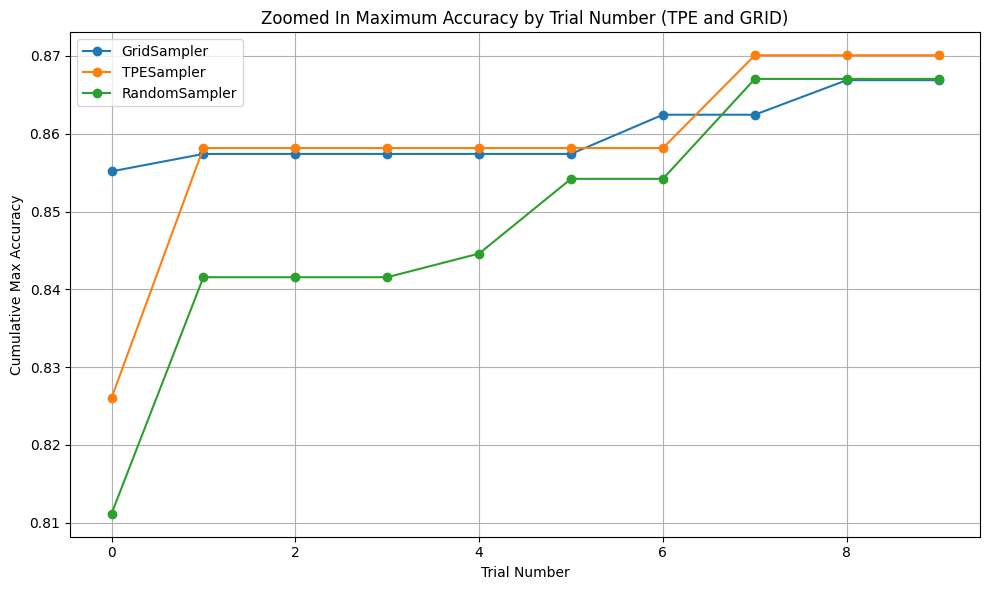

In [65]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Read in the CSV. Update 'your_file.csv' to the correct filename/path.
file_path = "Lab-2/search_type_results_colab.csv"

# Load the CSV file
df = pd.read_csv(file_path)

# Print the dataframe for verification
print("Original DataFrame:\n", df)

# Clean column names and values
df.columns = df.columns.str.strip()
df['Type'] = df['Type'].str.strip()

# Remove NaN values from the accuracy column
df.dropna(subset=['accuracy'], inplace=True)

# Convert accuracy column to float (if necessary)
df['accuracy'] = pd.to_numeric(df['accuracy'], errors='coerce')

# Verify cleaned data
print("Cleaned DataFrame:\n", df)

# 2. Split into three DataFrames: one for each sampler
df_grid = df[df['Type'] == 'GRID'].copy()
df_tpe  = df[df['Type'] == 'TPE'].copy()
df_random = df[df['Type'] == 'Random'].copy()

# 3. Compute running (cumulative) max for each row in chronological order
df_grid['cumulative_max'] = df_grid['accuracy'].cummax()
df_tpe['cumulative_max']  = df_tpe['accuracy'].cummax()
df_random['cumulative_max'] = df_random['accuracy'].cummax()

# 4. Plot the running max accuracy vs. trial number
plt.figure(figsize=(10, 6))
plt.plot(df_grid['trial_number'], df_grid['cumulative_max'], label='GridSampler', marker='o')
plt.plot(df_tpe['trial_number'],  df_tpe['cumulative_max'],  label='TPESampler', marker='o')
plt.plot(df_random['trial_number'], df_random['cumulative_max'], label='RandomSampler', marker='o')

plt.title('Zoomed In Maximum Accuracy by Trial Number (TPE and GRID)')
plt.xlabel('Trial Number')
plt.ylabel('Cumulative Max Accuracy')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


### Task 2 - Results PLotting

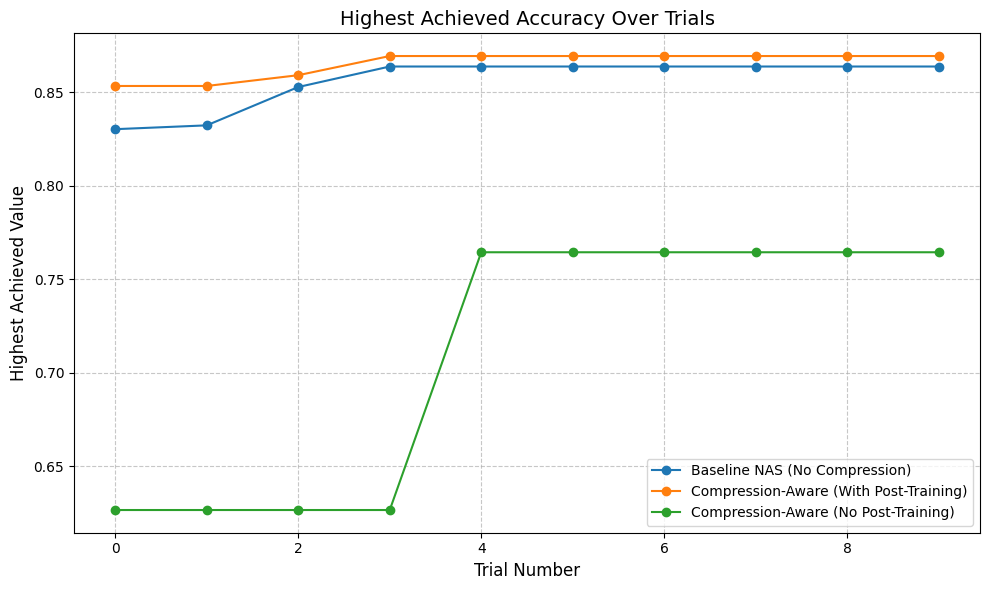

In [68]:
import pandas as pd
import matplotlib.pyplot as plt

# Folder path where the CSV files are located
folder_path = "Lab-2/"

# File paths
files = {
    "Baseline NAS (No Compression)": f"{folder_path}baseline_study_results.csv",
    "Compression-Aware (With Post-Training)": f"{folder_path}compress_with_post_study_results.csv",
    "Compression-Aware (No Post-Training)": f"{folder_path}compress_no_post_study_results.csv"
}

# Prepare a dictionary to hold the data
data = {}

# Read and process each file
for label, file_path in files.items():
    # Read the CSV file
    df = pd.read_csv(file_path)
    
    # Sort by trial number to ensure the order is correct
    df = df.sort_values(by="trial_number")

    
    # Compute the highest value up to each trial
    df["highest_value"] = df["value"].cummax()
    
    # Store the trial numbers and highest values
    data[label] = (df["trial_number"], df["highest_value"])

# Plotting
plt.figure(figsize=(10, 6))

for label, (trial_numbers, highest_values) in data.items():
    plt.plot(trial_numbers, highest_values, label=label, marker='o')

# Graph details
plt.title("Highest Achieved Accuracy Over Trials", fontsize=14)
plt.xlabel("Trial Number", fontsize=12)
plt.ylabel("Highest Achieved Value", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(fontsize=10)
plt.tight_layout()

# Show the graph
plt.show()
